Grid search fusion weight `alpha` untuk:
```
prob_fused = alpha * prob_text + (1 - alpha) * prob_image
```

# Import Libraries

In [1]:
import json
import pickle
import re
from pathlib import Path
from urllib.parse import unquote, urlparse

import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt

I0000 00:00:1781191609.552367   47710 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781191609.552717   47710 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781191609.591316   47710 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781191610.506579   47710 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
def clean_url(url):
    parsed = urlparse(url)
    url = parsed.netloc + parsed.path
    url = unquote(url).lower()
    url = re.sub(r"https?:\/\/", "", url)
    url = re.sub(r"[-_/]", " ", url)
    url = re.sub(r"[^a-zA-Z0-9\s]", " ", url)
    url = re.sub(r"(\d)([a-z])", r"\1 \2", url)
    url = re.sub(r"([a-z])(\d)", r"\1 \2", url)
    url = re.sub(r"\s+", " ", url).strip()
    return url

In [3]:
BASE_DIR = Path(".")
BIN_DIR = BASE_DIR / "bin"
CSV_PATH = BASE_DIR / "dataset" / "dataset_crawl_070526_with_images_path.csv"

# Load Models

In [4]:
text_model = tf.keras.models.load_model(str(BIN_DIR / "text_classifier.keras"))
with open(BIN_DIR / "text_tfidf_vectorizer.pkl", "rb") as f:
    text_vectorizer = pickle.load(f)
with open(BIN_DIR / "text_best_threshold.json") as f:
    text_cfg = json.load(f)
text_threshold = text_cfg.get("best_threshold", 0.63)
print(f"Text threshold: {text_threshold:.2f}")

Text threshold: 0.63


E0000 00:00:1781191611.138277   47710 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
image_model = joblib.load(BIN_DIR / "image_classifier.pkl")
image_scaler = joblib.load(BIN_DIR / "image_scaler.pkl")
with open(BIN_DIR / "image_best_threshold.json") as f:
    image_cfg = json.load(f)
image_threshold = image_cfg["threshold"]
print(f"Image threshold: {image_threshold:.2f}")
print(f"Image model: {type(image_model).__name__}")
if hasattr(image_model, "n_estimators"):
    print(f"n_estimators={image_model.n_estimators}, max_depth={image_model.max_depth}")

Image threshold: 0.52
Image model: RandomForestClassifier
n_estimators=500, max_depth=25


# Load Dataset

In [6]:
df = pd.read_csv(CSV_PATH)
mask = df["Screenshot_Path"].notna() & (df["Screenshot_Path"] != "")
df_img = df[mask].copy().reset_index(drop=True)

X_img = np.load(BIN_DIR / "image_features.npy")
img_ids = np.load(BIN_DIR / "image_ids.npy")
id_map = {i: idx for idx, i in enumerate(img_ids)}
order = [id_map[wid] for wid in df_img["Webpage_id"]]
X_img = X_img[order]

y = (df_img["Tag"] == "gambling").astype(int).values
print(f"Samples: {len(df_img)}")
print(f"Gambling: {y.sum()} / Non-gambling: {(1 - y).sum()}")

Samples: 37811
Gambling: 12503 / Non-gambling: 25308


# Predictions from Both Models

In [7]:
print("Getting text predictions...")
X_text = df_img["Url"].apply(clean_url).values
X_text_tfidf = text_vectorizer.transform(X_text)
X_text_tfidf.sort_indices()
prob_text = text_model.predict(X_text_tfidf, verbose=0).flatten()
print(f"Text prob range: {prob_text.min():.4f} - {prob_text.max():.4f}")

Getting text predictions...
Text prob range: 0.0000 - 1.0000


In [8]:
prob_image = image_model.predict_proba(X_img)[:, 1]
print(f"Image prob range: {prob_image.min():.4f} - {prob_image.max():.4f}")

Image prob range: 0.0000 - 0.9995


# Grid Search Fusion Weight Alpha

In [9]:
results = []
best_alpha = 0.5
best_f1 = 0.0
best_th = 0.5

for alpha in np.arange(0.0, 1.05, 0.05):
    prob_fused = alpha * prob_text + (1.0 - alpha) * prob_image
    best_f1_alpha = 0.0
    best_th_alpha = 0.5
    for th in np.arange(0.3, 0.85, 0.02):
        f1 = f1_score(y, (prob_fused >= th).astype(int))
        if f1 > best_f1_alpha:
            best_f1_alpha = f1
            best_th_alpha = th
    results.append({
        "alpha": round(alpha, 2),
        "threshold": round(float(best_th_alpha), 2),
        "f1": round(float(best_f1_alpha), 4),
    })
    if best_f1_alpha > best_f1:
        best_f1 = best_f1_alpha
        best_alpha = alpha
        best_th = best_th_alpha

In [10]:
results_df = pd.DataFrame(results)
display(results_df)

text_f1 = f1_score(y, (prob_text >= text_threshold).astype(int))
image_f1 = f1_score(y, (prob_image >= image_threshold).astype(int))

print(f"\nText-only F1 (th={text_threshold:.2f}):  {text_f1:.4f}")
print(f"Image-only F1 (th={image_threshold:.2f}): {image_f1:.4f}")
print(f"\nBest alpha: {best_alpha:.2f}")
print(f"Threshold: {best_th:.2f}")
print(f"Fusion F1: {best_f1:.4f}")

,alpha,threshold,f1
0,0.00,0.52,0.9901
1,0.05,0.54,0.9923
2,0.10,0.52,0.9936
3,0.15,0.54,0.9950
4,0.20,0.54,0.9964
5,0.25,0.56,0.9974
6,0.30,0.52,0.9984
7,0.35,0.52,0.9990
8,0.40,0.54,0.9993
9,0.45,0.48,0.9991



Text-only F1 (th=0.63):  0.9947
Image-only F1 (th=0.52): 0.9901

Best alpha: 0.40
Threshold: 0.54
Fusion F1: 0.9993


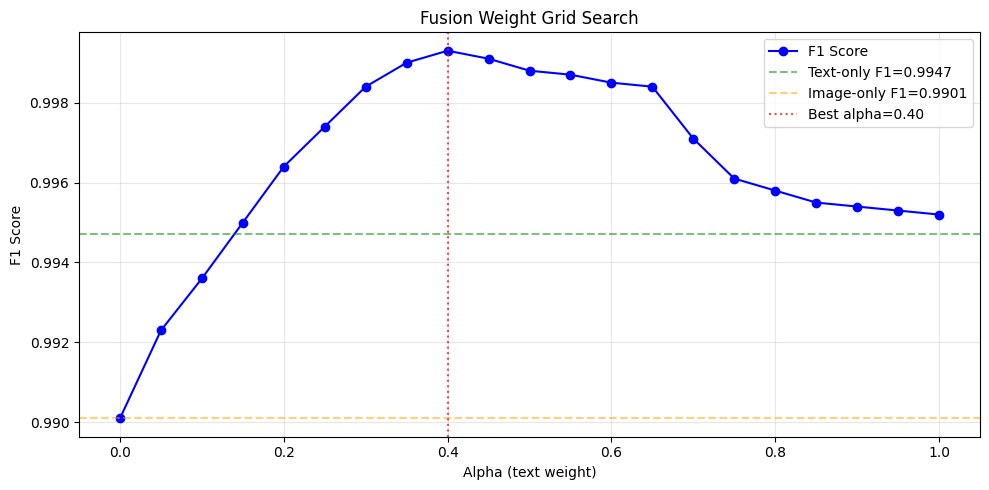

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(results_df["alpha"], results_df["f1"], "bo-", label="F1 Score")
ax1.axhline(text_f1, color="green", linestyle="--", alpha=0.5, label=f"Text-only F1={text_f1:.4f}")
ax1.axhline(image_f1, color="orange", linestyle="--", alpha=0.5, label=f"Image-only F1={image_f1:.4f}")
ax1.axvline(best_alpha, color="red", linestyle=":", alpha=0.7, label=f"Best alpha={best_alpha:.2f}")
ax1.set_xlabel("Alpha (text weight)")
ax1.set_ylabel("F1 Score")
ax1.set_title("Fusion Weight Grid Search")
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save Optimal Alpha

In [12]:
output = {"alpha": float(best_alpha), "threshold": float(best_th), "f1": float(best_f1)}
with open(BIN_DIR / "image_fusion_alpha.json", "w") as f:
    json.dump(output, f)

print(f"Saved to {BIN_DIR / 'image_fusion_alpha.json'}")
print(json.dumps(output, indent=2))

Saved to bin/image_fusion_alpha.json
{
  "alpha": 0.4,
  "threshold": 0.5400000000000003,
  "f1": 0.9992800575953924
}


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/rizkyfauziilmi/Documents/Code/Kuliah/gambling-blocker/backend/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/home/rizkyfauziilmi/Documents/Code/Kuliah/gambling-blocker/backend/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 348, in dispatch_control
    await self.process_control(msg)
  File "/home/rizkyfauziilmi/Documents/Code/Kuliah/gambling-blocker/backend/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 354, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
                  ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/home/rizkyfauziilmi/Documents/Code/Kuliah/gambling-blocker/backend/.venv/lib/python3.13/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM